In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
from pathlib import Path
import pandas as pd

nav_file = Path("../data/raw/1788499983331-4389156d-02_nav_history.csv")

nav = pd.read_csv(nav_file)

nav["date"] = pd.to_datetime(nav["date"])

print("Shape:", nav.shape)
print("Schemes:", nav["amfi_code"].nunique())
print(nav.head())

Shape: (46000, 3)
Schemes: 40
   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.head(10))
print("\nMissing daily returns:", nav["daily_return"].isna().sum())
print("\nDaily return statistics:")
print(nav["daily_return"].describe())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073

Missing daily returns: 40

Daily return statistics:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


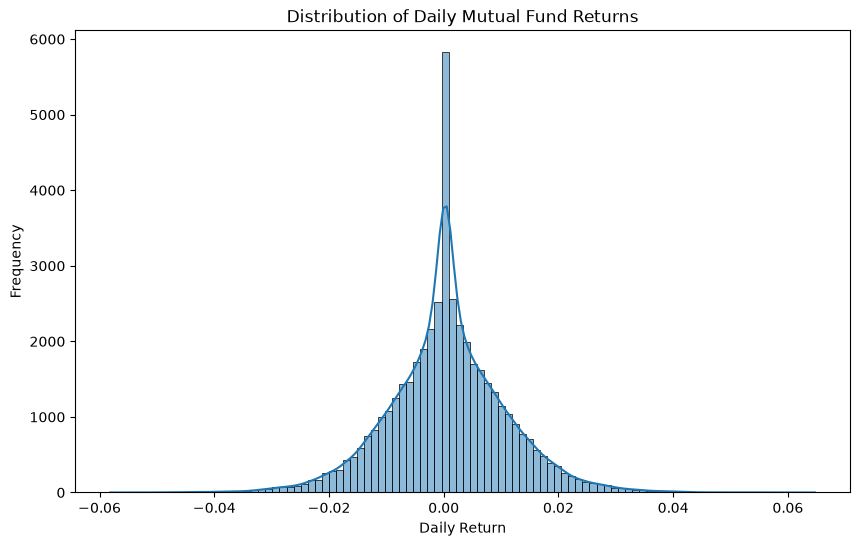

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [6]:
latest_date = nav["date"].max()

print("Latest NAV date:", latest_date)

periods = {
    "1Y": 1,
    "3Y": 3,
    "5Y": 5
}

cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    latest_row = group.iloc[-1]
    latest_nav = latest_row["nav"]

    result = {
        "amfi_code": amfi_code
    }

    for period_name, years in periods.items():

        start_date = latest_date - pd.DateOffset(years=years)

        eligible = group[group["date"] <= start_date]

        if len(eligible) > 0:

            start_row = eligible.iloc[-1]
            start_nav = start_row["nav"]

            actual_years = (
                latest_row["date"] - start_row["date"]
            ).days / 365.25

            cagr = (latest_nav / start_nav) ** (1 / actual_years) - 1

            result[f"CAGR_{period_name}"] = cagr

        else:
            result[f"CAGR_{period_name}"] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())
print("\nShape:", cagr_df.shape)

Latest NAV date: 2026-05-29 00:00:00
   amfi_code   CAGR_1Y   CAGR_3Y  CAGR_5Y
0     100016 -0.022258  0.012924      NaN
1     100025  0.037076  0.039155      NaN
2     100033  0.532772  0.324340      NaN
3     101206  0.479638  0.289602      NaN
4     101207 -0.240003 -0.041515      NaN

Shape: (40, 4)


In [7]:
cagr_table = cagr_df.copy()

cagr_table["CAGR_1Y"] = cagr_table["CAGR_1Y"] * 100
cagr_table["CAGR_3Y"] = cagr_table["CAGR_3Y"] * 100
cagr_table["CAGR_5Y"] = cagr_table["CAGR_5Y"] * 100

cagr_table = cagr_table.sort_values(
    "CAGR_3Y",
    ascending=False
).reset_index(drop=True)

print(cagr_table.to_string(index=False))

 amfi_code    CAGR_1Y    CAGR_3Y  CAGR_5Y
    119094  22.277897  35.102528      NaN
    148567  20.375957  33.991970      NaN
    120504  13.073788  32.478927      NaN
    100033  53.277195  32.433971      NaN
    120505  29.627681  31.769243      NaN
    119551  60.489297  30.448613      NaN
    120843  26.677584  29.575111      NaN
    148569  39.783803  29.171358      NaN
    101206  47.963794  28.960211      NaN
    149324  65.195466  26.993503      NaN
    149323  21.497414  26.863104      NaN
    119598  82.851575  26.663091      NaN
    102887  13.593044  25.549670      NaN
    118632  34.007896  22.646647      NaN
    118633  25.559540  21.084691      NaN
    119093  19.781539  20.811560      NaN
    118635  22.510248  20.003216      NaN
    102885  20.222859  19.662361      NaN
    125497  28.697580  18.429918      NaN
    120506  41.852990  18.417429      NaN
    149322  18.124619  18.039740      NaN
    120841  16.849552  17.263014      NaN
    119552   5.710118  16.263375  

In [8]:
RF_ANNUAL = 0.065
RF_DAILY = (1 + RF_ANNUAL) ** (1 / 252) - 1

sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    excess_returns = returns - RF_DAILY

    sharpe = (
        excess_returns.mean()
        / returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

print(sharpe_df.to_string(index=False))

 amfi_code  Sharpe_Ratio
    148567      1.462504
    120843      1.319442
    148569      1.246344
    119551      1.222947
    120505      1.190559
    149323      1.143490
    100033      1.104352
    118632      1.095918
    101206      1.041061
    120504      1.040569
    119094      1.008626
    119552      0.967752
    149324      0.957917
    119598      0.953332
    148568      0.939362
    120507      0.904162
    102885      0.832815
    120503      0.812502
    125497      0.789543
    118635      0.680395
    120506      0.662124
    118633      0.659620
    102887      0.632319
    120841      0.509256
    149322      0.478092
    118634      0.456426
    125498      0.311604
    120844      0.304252
    101207      0.170481
    119093      0.144041
    120842      0.087273
    119092      0.045245
    119599     -0.049101
    119095     -0.067926
    119120     -0.175723
    100016     -0.187650
    102886     -0.194707
    118636     -0.306013
    101208     -0.417229


In [9]:
sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # Only negative return days
    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    sortino = (
        (returns.mean() - RF_DAILY)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

print(sortino_df.to_string(index=False))

 amfi_code  Sortino_Ratio
    148567       2.409056
    120843       2.387295
    148569       2.166757
    119551       2.166272
    120505       2.047336
    120507       1.918995
    149323       1.893929
    118632       1.874521
    100033       1.846950
    120504       1.829993
    101206       1.823822
    119094       1.721540
    119598       1.689537
    148568       1.655788
    119552       1.634215
    149324       1.633643
    102885       1.463356
    120503       1.362304
    125497       1.354240
    118633       1.180264
    118635       1.164572
    120506       1.118265
    102887       1.111253
    120841       0.888722
    149322       0.785211
    118634       0.759310
    120844       0.643570
    125498       0.527418
    101207       0.289943
    119093       0.245695
    120842       0.143190
    119092       0.077269
    119599      -0.081042
    119095      -0.114607
    119120      -0.292206
    100016      -0.326892
    102886      -0.328457
    118636  

In [10]:
benchmark = pd.read_csv(
    "../data/raw/1788499982615-f9647ab2-10_benchmark_indices.csv"
)
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [11]:
from scipy.stats import linregress

# Get NIFTY100 data
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Calculate NIFTY100 daily returns
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

# Keep only required columns
nifty100 = nifty100[
    ["date", "benchmark_return"]
].dropna()

alpha_beta_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    fund = group[
        ["date", "daily_return"]
    ].dropna()

    # Match fund returns with NIFTY100 returns
    merged = pd.merge(
        fund,
        nifty100,
        on="date",
        how="inner"
    )

    # OLS regression
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope
    alpha_daily = regression.intercept
    alpha_annual = alpha_daily * 252

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "Alpha": alpha_annual,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print(alpha_beta_df.to_string(index=False))

 amfi_code    Alpha      Beta
    100016 0.037476 -0.058268
    100025 0.042818  0.001158
    100033 0.271954  0.005104
    101206 0.213998  0.021086
    101207 0.108971 -0.065289
    101208 0.060861  0.000267
    102885 0.170488 -0.019487
    102886 0.028969 -0.042125
    102887 0.162113  0.016683
    118632 0.218294 -0.008354
    118633 0.156438 -0.036639
    118634 0.175007  0.103497
    118635 0.151364 -0.001434
    118636 0.050748  0.001257
    119092 0.068995  0.009731
    119093 0.082328  0.025883
    119094 0.260767 -0.066265
    119095 0.048016 -0.066951
    119120 0.056209 -0.006414
    119551 0.232010 -0.031751
    119552 0.198686 -0.026159
    119598 0.303370 -0.023196
    119599 0.048824  0.062002
    120503 0.177033 -0.040269
    120504 0.211948  0.016232
    120505 0.292636  0.000549
    120506 0.162539  0.041896
    120507 0.067462 -0.000444
    120841 0.130429  0.036356
    120842 0.078044  0.018057
    120843 0.273305 -0.022830
    120844 0.064557 -0.000401
    125497

In [12]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum drawdown
    min_idx = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_idx, "drawdown"]
    trough_date = group.loc[min_idx, "date"]

    # Peak date before the trough
    peak_data = group[
        group["date"] <= trough_date
    ]

    peak_idx = peak_data["nav"].idxmax()
    peak_date = group.loc[peak_idx, "date"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "Max_Drawdown": max_drawdown,
        "Peak_Date": peak_date,
        "Trough_Date": trough_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.sort_values(
    "Max_Drawdown",
    ascending=True
).reset_index(drop=True)

print(drawdown_df.to_string(index=False))

 amfi_code  Max_Drawdown  Peak_Date Trough_Date
    119599     -0.525742 2023-01-17  2025-10-28
    119095     -0.516778 2025-05-22  2026-05-11
    101207     -0.354469 2024-11-21  2026-05-11
    149324     -0.311719 2024-05-03  2025-01-03
    119598     -0.287060 2024-08-28  2025-05-14
    102886     -0.280011 2025-01-07  2026-04-27
    100016     -0.247344 2022-03-30  2022-09-15
    120842     -0.240035 2023-11-09  2024-10-17
    118634     -0.233449 2025-04-09  2026-02-20
    119093     -0.217514 2022-02-24  2023-05-22
    102887     -0.215398 2022-01-03  2022-07-04
    125498     -0.211173 2025-04-04  2025-09-12
    119094     -0.209609 2022-04-14  2022-08-11
    120506     -0.198257 2023-03-31  2023-08-14
    118633     -0.186297 2023-10-30  2024-02-29
    120505     -0.181885 2024-10-24  2025-01-23
    120841     -0.175736 2024-01-09  2025-02-14
    118632     -0.174141 2024-01-02  2024-07-19
    149323     -0.172481 2022-06-06  2022-10-24
    148569     -0.163967 2023-08-10  202

In [13]:
# Merge all required metrics
scorecard = cagr_df[
    ["amfi_code", "CAGR_3Y"]
].merge(
    sharpe_df,
    on="amfi_code"
).merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
).merge(
    drawdown_df[["amfi_code", "Max_Drawdown"]],
    on="amfi_code"
)

# Load fund master for expense ratio
fund_master = pd.read_csv(
    "data/raw/1788499983024-b042c300-01_fund_master.csv"
)

print(fund_master.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/1788499983024-b042c300-01_fund_master.csv'

In [ ]:
# Add expense ratio
scorecard = scorecard.merge(
    fund_master[
        ["amfi_code", "scheme_name", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

# Create percentile ranks
scorecard["Return_Score"] = (
    scorecard["CAGR_3Y"].rank(pct=True) * 100
)

scorecard["Sharpe_Score"] = (
    scorecard["Sharpe_Ratio"].rank(pct=True) * 100
)

scorecard["Alpha_Score"] = (
    scorecard["Alpha"].rank(pct=True) * 100
)

# Lower expense ratio is better
scorecard["Expense_Score"] = (
    scorecard["expense_ratio_pct"].rank(
        ascending=False,
        pct=True
    ) * 100
)

# Lower drawdown is better
scorecard["Drawdown_Score"] = (
    scorecard["Max_Drawdown"].rank(
        ascending=False,
        pct=True
    ) * 100
)

# Final weighted score
scorecard["Fund_Score"] = (
    0.30 * scorecard["Return_Score"]
    + 0.25 * scorecard["Sharpe_Score"]
    + 0.20 * scorecard["Alpha_Score"]
    + 0.15 * scorecard["Expense_Score"]
    + 0.10 * scorecard["Drawdown_Score"]
)

# Rank funds
scorecard["Rank"] = (
    scorecard["Fund_Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

print(
    scorecard[
        [
            "Rank",
            "amfi_code",
            "scheme_name",
            "CAGR_3Y",
            "Sharpe_Ratio",
            "Alpha",
            "expense_ratio_pct",
            "Max_Drawdown",
            "Fund_Score"
        ]
    ].to_string(index=False)
)

In [ ]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Saved: fund_scorecard.csv")
print("Rows:", len(scorecard))

In [ ]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

print("Saved: alpha_beta.csv")
print("Rows:", len(alpha_beta_df))
print(alpha_beta_df.head(10).to_string(index=False))

In [ ]:
# Prepare NIFTY 50 and NIFTY 100 benchmark data

benchmark = benchmark.sort_values("date").copy()

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
][["date", "close_value"]].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "close_value"]].copy()

nifty50["NIFTY50_Return"] = nifty50["close_value"].pct_change()
nifty100["NIFTY100_Return"] = nifty100["close_value"].pct_change()

print("NIFTY50 rows:", len(nifty50))
print("NIFTY100 rows:", len(nifty100))

print("\nNIFTY50:")
print(nifty50.head())

print("\nNIFTY100:")
print(nifty100.head())

In [ ]:
top5 = scorecard.head(5).copy()

print("Top 5 Funds:")
print(
    top5[
        ["Rank", "amfi_code", "scheme_name", "Fund_Score"]
    ].to_string(index=False)
)

In [ ]:
top5_codes = top5["amfi_code"].tolist()

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav[
    ["date", "amfi_code", "nav", "daily_return"]
].copy()

# Keep approximately the latest 3 years
end_date = top5_nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

# Merge NIFTY 50 and NIFTY 100
benchmark_3y = pd.merge(
    nifty50[["date", "NIFTY50_Return"]],
    nifty100[["date", "NIFTY100_Return"]],
    on="date",
    how="inner"
)

benchmark_3y = benchmark_3y[
    benchmark_3y["date"] >= start_date
]

comparison_data = pd.merge(
    top5_nav,
    benchmark_3y,
    on="date",
    how="inner"
)

print("Comparison rows:", len(comparison_data))
print(comparison_data.head())

In [ ]:
tracking_error_results = []

for amfi_code, group in comparison_data.groupby("amfi_code"):

    fund_returns = group["daily_return"].dropna()

    # Align benchmark returns with fund returns
    aligned = group[
        ["daily_return", "NIFTY50_Return", "NIFTY100_Return"]
    ].dropna()

    tracking_error_50 = (
        aligned["daily_return"] - aligned["NIFTY50_Return"]
    ).std() * np.sqrt(252)

    tracking_error_100 = (
        aligned["daily_return"] - aligned["NIFTY100_Return"]
    ).std() * np.sqrt(252)

    tracking_error_results.append({
        "amfi_code": amfi_code,
        "Tracking_Error_NIFTY50": tracking_error_50,
        "Tracking_Error_NIFTY100": tracking_error_100
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df = tracking_error_df.merge(
    top5[["amfi_code", "scheme_name", "Rank"]],
    on="amfi_code",
    how="left"
).sort_values("Rank")

print(tracking_error_df.to_string(index=False))

In [ ]:
plt.figure(figsize=(14, 8))

# Plot each top 5 fund
for amfi_code in top5_codes:
    fund_data = comparison_data[
        comparison_data["amfi_code"] == amfi_code
    ].sort_values("date").copy()

    # Cumulative growth from daily returns
    cumulative_return = (
        (1 + fund_data["daily_return"].fillna(0))
        .cumprod()
    )

    scheme_name = top5.loc[
        top5["amfi_code"] == amfi_code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        fund_data["date"],
        cumulative_return,
        label=scheme_name
    )

# NIFTY 50 cumulative growth
benchmark_plot = comparison_data[
    ["date", "NIFTY50_Return", "NIFTY100_Return"]
].drop_duplicates("date").sort_values("date")

nifty50_growth = (
    (1 + benchmark_plot["NIFTY50_Return"].fillna(0))
    .cumprod()
)

nifty100_growth = (
    (1 + benchmark_plot["NIFTY100_Return"].fillna(0))
    .cumprod()
)

plt.plot(
    benchmark_plot["date"],
    nifty50_growth,
    label="NIFTY50"
)

plt.plot(
    benchmark_plot["date"],
    nifty100_growth,
    label="NIFTY100"
)

plt.title("Top 5 Mutual Funds vs NIFTY50 and NIFTY100 - 3 Years")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: benchmark_comparison.png")

In [ ]:
from pathlib import Path

files = [
    "Performance_Analytics.ipynb",
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "benchmark_comparison.png"
]

for file in files:
    path = Path(file)
    print(f"{file}: {'FOUND' if path.exists() else 'MISSING'}")